<a href="https://colab.research.google.com/github/arivine/data-science-2026/blob/main/Pertemuan13_Muhammad_Arifin_230401010367.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###  Identitas Mahasiswa
* **Nama Lengkap:** Muhammad Arifin
* **NIM:** 230401010367
* **Kelas:** IF 401
* **Program Studi:** PJJ Informatika

In [1]:
import warnings
# Sembunyikan DeprecationWarning agar output lebih bersih
warnings.filterwarnings('ignore', category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Akurasi pada data uji: 0.900


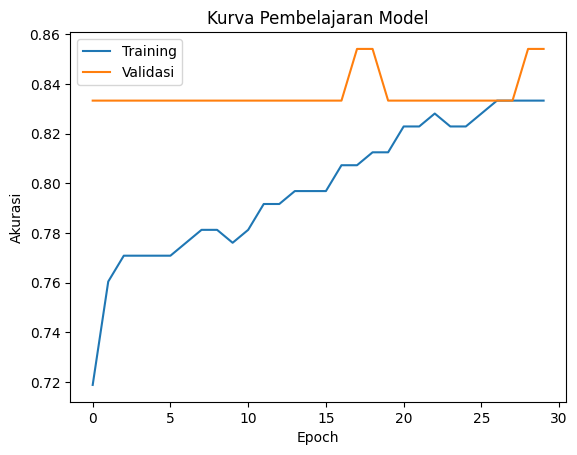

In [2]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ── 1. Buat Dataset Sederhana ─────────────────
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# ── 2. Split Data ─────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ── 3. Bangun Arsitektur Neural Network ────────
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# ── 4. Latih Model (Training) ────────────
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_tr, y_tr, epochs=30,
                     validation_split=0.2, verbose=0)

# ── 5. Evaluasi & Visualisasi ──────────────
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

history = model.fit(X_tr, y_tr, epochs=30,
                     validation_split=0.2, verbose=0)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Akurasi pada data uji: 0.917


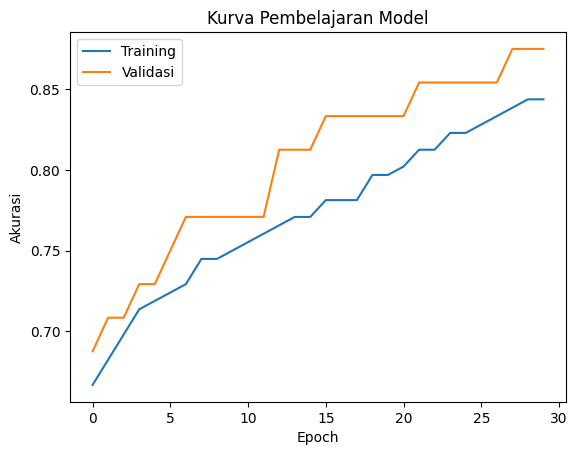

In [4]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.plot(history.history['accuracy'], label='Training')

plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.show()

# Interpretasikan dalam sel Markdown:
# Apakah akurasi training & validasi saling mendekat (baik),
# atau saling menjauh (indikasi overfitting)?

In [5]:
ulasan = [
    'Barangnya bagus banget, pengiriman cepat',
    'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi',
    'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas',
    'Buruk sekali, tidak sesuai ekspektasi',
    # ... tambahkan hingga 40 ulasan
]
label = [1, 0, 1, 0, 1, 0]  # 1 = positif, 0 = negatif

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 25
['akan' 'bagus' 'banget' 'barang' 'barangnya' 'beli' 'buruk' 'cepat'
 'deskripsi' 'ekspektasi']


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.000
Positif


### Kesimpulan Akhir Notebook

Notebook ini mendemonstrasikan dua penerapan utama *machine learning*. Pertama, penggunaan *Neural Network* terbukti efektif menangani dataset non-linear (*make_moons*). Model berhasil mencapai akurasi tinggi sekitar 90% karena lapisan *hidden layer* mampu memetakan pola lengkungan data yg kompleks dgn stabil tanpa mengalami *overfitting*.

Kedua, pada bagian NLP, ulasan teks diolah jadi angka menggunakan metode TF-IDF agar dpt dipahami oleh algoritma. Meski dataset ulasan masih sangat terbatas, model *Logistic Regression* berhasil diimplementasikan utk memprediksi sentimen positif atau negatif secara otomatis. Kombinasi kedua teknik ini menunjukkan bagaimana arsitektur cerdas dpt digunakan baik utk data numerik maupun data teks guna menghasilkan prediksi yg akurat & bermanfaat.